# Unit14_Example_05 | 化工設備故障時間之可靠度分析與 Weibull 分布擬合

本 Notebook 以 **化工泵浦設備的壽命數據** 為題，示範 `scipy.stats.weibull_min` 的完整可靠度分析流程。

## 目標
- 使用 `scipy.stats.weibull_min.rvs()` 生成模擬故障時間數據（形狀參數 $k=2.5$ ，比例參數 $\lambda=1000$ h）
- 使用 `scipy.stats.weibull_min.fit()` 以 MLE 估計 Weibull 形狀參數 $k$ 與比例參數 $\lambda$
- 以 `scipy.stats.kstest()` (Kolmogorov-Smirnov 檢定) 驗證數據與擬合分布之適合度
- 計算可靠度函數 $R(t)$ 、故障率函數 $h(t)$ 、 $B_{10}$ 壽命與 MTTF
- 繪製故障時間直方圖、存活函數曲線與故障率曲線（浴缸曲線）

---
### 0. 環境設定

In [18]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit14_Example_05'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit14'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit14
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_05
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_05\figs


---
### 1. 載入套件

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.special as sp
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})

print("✓ 套件載入完成")
print(f"  numpy  : {np.__version__}")
print(f"  scipy  : {scipy.__version__}")

✓ 套件載入完成
  numpy  : 1.23.5
  scipy  : 1.15.2


---
### 2. Weibull 分布模擬數據生成

以 `scipy.stats.weibull_min.rvs()` 生成 50 台泵浦的模擬故障時間，真實參數：形狀參數 $k=2.5$ （老化型故障），比例參數 $\lambda=1000$ h。

In [20]:
# ===== 真實參數設定 =====
k_true      = 2.5       # 形狀參數 (老化型故障)
lambda_true = 1000.0    # 比例參數 (h)
n_pumps     = 50        # 樣本數 (50 台泵浦)

# ===== 生成模擬故障時間數據 =====
rng = np.random.default_rng(seed=42)
ttf_data = stats.weibull_min.rvs(c=k_true, scale=lambda_true,
                                  loc=0, size=n_pumps,
                                  random_state=rng)

# 排序後顯示統計摘要
ttf_sorted = np.sort(ttf_data)
print("=" * 50)
print(f"  Weibull 分布故障時間模擬數據 (n={n_pumps})")
print("=" * 50)
print(f"  真實參數: k={k_true}, λ={lambda_true} h")
print(f"  最短壽命 : {ttf_data.min():.1f} h")
print(f"  最長壽命 : {ttf_data.max():.1f} h")
print(f"  樣本均值 : {ttf_data.mean():.1f} h")
print(f"  樣本標準差: {ttf_data.std():.1f} h")
print(f"  中位數   : {np.median(ttf_data):.1f} h")
print()
print("  前 10 筆故障時間 (hours):")
print("  ", np.round(ttf_sorted[:10], 1))

  Weibull 分布故障時間模擬數據 (n=50)
  真實參數: k=2.5, λ=1000.0 h
  最短壽命 : 288.7 h
  最長壽命 : 1690.2 h
  樣本均值 : 928.1 h
  樣本標準差: 348.5 h
  中位數   : 879.0 h

  前 10 筆故障時間 (hours):
   [288.7 337.  396.4 451.7 454.4 468.9 489.4 535.7 542.2 581.1]


---
### 3. Weibull 分布參數估計（MLE）

使用 `scipy.stats.weibull_min.fit(data, floc=0)` 以最大概似估計法（MLE）估計形狀參數 $k$ 與比例參數 $\lambda$ 。設定 `floc=0` 固定位置參數為零（兩參數 Weibull 分布）。

In [21]:
# ===== MLE 參數估計 =====
# fit() 回傳 (c, loc, scale)，即 (k, t0, λ)
c_hat, loc_hat, scale_hat = stats.weibull_min.fit(ttf_data, floc=0)
# floc=0：固定位置參數為 0（兩參數 Weibull）

k_hat      = c_hat
lambda_hat = scale_hat

# 建構擬合後的分布物件（供後續 CDF、PDF、SF 計算）
weibull_fitted = stats.weibull_min(c=k_hat, loc=0, scale=lambda_hat)

print("=" * 50)
print("  Weibull 分布 MLE 參數估計結果")
print("=" * 50)
print(f"  估計形狀參數  k̂  = {k_hat:.4f}   (真實值: {k_true})")
print(f"  估計比例參數  λ̂  = {lambda_hat:.2f} h (真實值: {lambda_true} h)")
print(f"  固定位置參數 t₀  = {loc_hat:.1f}   (固定為 0)")
print()
print(f"  形狀參數估計誤差: {abs(k_hat - k_true)/k_true * 100:.2f}%")
print(f"  比例參數估計誤差: {abs(lambda_hat - lambda_true)/lambda_true * 100:.2f}%")

  Weibull 分布 MLE 參數估計結果
  估計形狀參數  k̂  = 2.9217   (真實值: 2.5)
  估計比例參數  λ̂  = 1042.50 h (真實值: 1000.0 h)
  固定位置參數 t₀  = 0.0   (固定為 0)

  形狀參數估計誤差: 16.87%
  比例參數估計誤差: 4.25%


---
### 4. K-S 適合度檢定

使用 `scipy.stats.kstest()` 計算 Kolmogorov-Smirnov 統計量 $D_n$ 與 p 值，驗證數據是否符合 MLE 擬合的 Weibull 分布。

**假設：**
- $H_0$ ：數據來自所擬合的 Weibull 分布
- $H_1$ ：數據不來自所擬合的 Weibull 分布
- 顯著水準 $\alpha = 0.05$

In [22]:
# ===== Kolmogorov-Smirnov 適合度檢定 =====
ks_stat, ks_pvalue = stats.kstest(ttf_data, weibull_fitted.cdf)

print("=" * 50)
print("  Kolmogorov-Smirnov 適合度檢定結果")
print("=" * 50)
print(f"  K-S 統計量 D   = {ks_stat:.4f}")
print(f"  p 值           = {ks_pvalue:.4f}")
print()
if ks_pvalue > 0.05:
    print("  結論: p > 0.05，無法拒絕 H₀")
    print("  → 數據與所擬合 Weibull 分布吻合 (適合度良好)")
else:
    print("  結論: p ≤ 0.05，拒絕 H₀")
    print("  → 數據不符合所擬合 Weibull 分布")

# ===== ECDF 計算（供後續繪圖用）=====
ttf_sort  = np.sort(ttf_data)
ecdf_vals = np.arange(1, n_pumps + 1) / n_pumps

print()
print("  前 8 個故障時間點 ECDF 與理論 CDF 比較：")
print(f"  {'時間(h)':>10}  {'ECDF':>8}  {'理論CDF':>8}  {'偏差':>8}")
print("  " + "-" * 44)
for i in range(8):
    t_i    = ttf_sort[i]
    ecdf_i = ecdf_vals[i]
    cdf_i  = weibull_fitted.cdf(t_i)
    print(f"  {t_i:>10.1f}  {ecdf_i:>8.4f}  {cdf_i:>8.4f}  {abs(ecdf_i-cdf_i):>8.4f}")

  Kolmogorov-Smirnov 適合度檢定結果
  K-S 統計量 D   = 0.0880
  p 值           = 0.8018

  結論: p > 0.05，無法拒絕 H₀
  → 數據與所擬合 Weibull 分布吻合 (適合度良好)

  前 8 個故障時間點 ECDF 與理論 CDF 比較：
       時間(h)      ECDF     理論CDF        偏差
  --------------------------------------------
       288.7    0.0200    0.0232    0.0032
       337.0    0.0400    0.0362    0.0038
       396.4    0.0600    0.0576    0.0024
       451.7    0.0800    0.0832    0.0032
       454.4    0.1000    0.0846    0.0154
       468.9    0.1200    0.0923    0.0277
       489.4    0.1400    0.1040    0.0360
       535.7    0.1600    0.1332    0.0268


---
### 5. 可靠度函數與故障率函數計算

利用 `weibull_fitted.sf(t)` 計算可靠度 $R(t)$ ，並以解析式計算故障率函數 $h(t) = k\,t^{k-1}/\lambda^k$ 。

In [23]:
# ===== 特定時刻的可靠度計算 =====
t_check = np.array([500, 800, 1000, 1200])

print("=" * 60)
print("  特定時刻的可靠度分析（使用 MLE 估計參數）")
print("=" * 60)
print(f"  估計參數: k̂={k_hat:.4f}, λ̂={lambda_hat:.2f} h")
print()
print(f"  {'時間 t (h)':>12}  {'R(t)':>10}  {'F(t)':>10}  {'h(t) (1/h)':>12}")
print("  " + "-" * 52)

for t in t_check:
    Rt = weibull_fitted.sf(t)
    Ft = weibull_fitted.cdf(t)
    ht = k_hat * t**(k_hat - 1) / lambda_hat**k_hat
    print(f"  {t:>12.0f}  {Rt:>10.4f}  {Ft:>10.4f}  {ht:>12.6f}")

print()
print("  解讀:")
print(f"  → t=500h 時，{weibull_fitted.sf(500)*100:.1f}% 的泵浦仍正常運作")
print(f"  → t=1000h 時，{weibull_fitted.sf(1000)*100:.1f}% 的泵浦仍正常運作")
print(f"  → t=λ̂={lambda_hat:.0f}h 時，{weibull_fitted.sf(lambda_hat)*100:.1f}% 存活")
print(f"    (Weibull 特徵壽命處存活率理論值恆為 e⁻¹ ≈ 36.8%)")

  特定時刻的可靠度分析（使用 MLE 估計參數）
  估計參數: k̂=2.9217, λ̂=1042.50 h

      時間 t (h)        R(t)        F(t)    h(t) (1/h)
  ----------------------------------------------------
           500      0.8897      0.1103      0.000683
           800      0.6304      0.3696      0.001685
          1000      0.4125      0.5875      0.002587
          1200      0.2213      0.7787      0.003673

  解讀:
  → t=500h 時，89.0% 的泵浦仍正常運作
  → t=1000h 時，41.3% 的泵浦仍正常運作
  → t=λ̂=1042h 時，36.8% 存活
    (Weibull 特徵壽命處存活率理論值恆為 e⁻¹ ≈ 36.8%)


---
### 6. 關鍵可靠度指標：$B_{10}$ 壽命與 MTTF

- **$B_{10}$ 壽命**：10% 設備累積故障對應的時間，即 `ppf(0.10)`，是預防性維護排程的基準
- **MTTF**：平均故障間隔時間 $= \lambda\,\Gamma(1 + 1/k)$ ，備品採購與壽命預測的依據

In [26]:
# ===== B10 壽命 =====
B10_hat  = weibull_fitted.ppf(0.10)
B10_true = lambda_true * (-np.log(0.90)) ** (1/k_true)

# ===== MTTF =====
MTTF_hat  = lambda_hat  * sp.gamma(1 + 1/k_hat)
MTTF_true = lambda_true * sp.gamma(1 + 1/k_true)

# ===== 樣本均值 =====
sample_mean = ttf_data.mean()

print("=" * 60)
print("  關鍵可靠度指標比較")
print("=" * 60)
print(f"  {'指標':>20}  {'真實值':>12}  {'MLE估計值':>12}")
print("  " + "-" * 50)
print(f"  {'B10 壽命 (h)':>20}  {B10_true:>12.1f}  {B10_hat:>12.1f}")
print(f"  {'MTTF (h)':>20}  {MTTF_true:>12.1f}  {MTTF_hat:>12.1f}")
print(f"  {'樣本均值 (h)':>20}  {'—':>12}  {sample_mean:>12.1f}")
print()
print(f"  B10 估計誤差  : {abs(B10_hat - B10_true)/B10_true * 100:.1f}%")
print(f"  MTTF 估計誤差 : {abs(MTTF_hat - MTTF_true)/MTTF_true * 100:.1f}%")
print()
print("  工程決策建議:")
print(f"  → B10={B10_hat:.0f} h: 建議在此時間前安排第一次預防性維護")
print(f"  → MTTF={MTTF_hat:.0f} h: 平均壽命，可規劃備用零件採購週期")
print(f"  → 樣本均值={sample_mean:.0f} h ≈ MTTF（兩者應相近，差異來自MLE誤差）")

  關鍵可靠度指標比較
                    指標           真實值        MLE估計值
  --------------------------------------------------
            B10 壽命 (h)         406.5         482.6
              MTTF (h)         887.3         929.9
              樣本均值 (h)             —         928.1

  B10 估計誤差  : 18.7%
  MTTF 估計誤差 : 4.8%

  工程決策建議:
  → B10=483 h: 建議在此時間前安排第一次預防性維護
  → MTTF=930 h: 平均壽命，可規劃備用零件採購週期
  → 樣本均值=928 h ≈ MTTF（兩者應相近，差異來自MLE誤差）


---
### 7. 視覺化分析

繪製四個子圖：
1. **故障時間直方圖 + Weibull PDF**：直觀檢視 MLE 擬合品質
2. **ECDF vs 理論 CDF**：K-S 適合度視覺化
3. **可靠度函數 $R(t)$**：標示 $B_{10}$ 、MTTF、特徵壽命
4. **故障率函數 $h(t)$** （浴缸曲線）：確認老化型故障特性

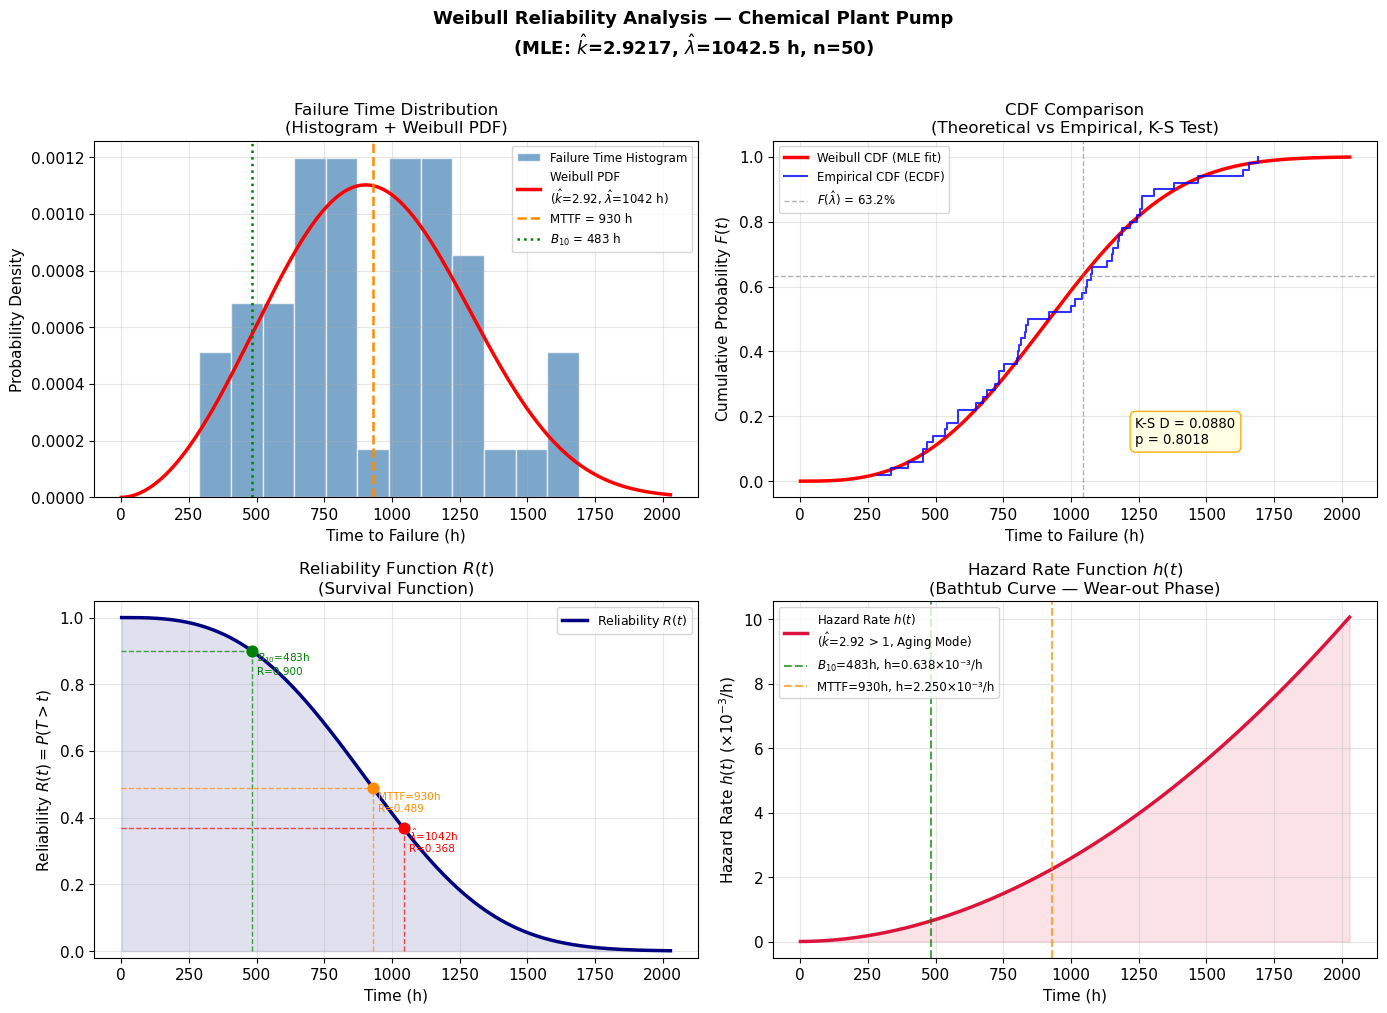

圖檔已儲存: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_05\figs\weibull_reliability_analysis.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

t_range  = np.linspace(1, ttf_data.max() * 1.2, 400)
pdf_fit  = weibull_fitted.pdf(t_range)
cdf_fit  = weibull_fitted.cdf(t_range)
sf_fit   = weibull_fitted.sf(t_range)
haz_fit  = k_hat * t_range**(k_hat - 1) / lambda_hat**k_hat

# -------- 子圖1: 直方圖 + Weibull PDF --------
ax1 = axes[0, 0]
ax1.hist(ttf_data, bins=12, density=True, color='steelblue',
         edgecolor='white', alpha=0.7, label='Failure Time Histogram')
ax1.plot(t_range, pdf_fit, 'r-', linewidth=2.5,
         label=f'Weibull PDF\n($\\hat{{k}}$={k_hat:.2f}, $\\hat{{\\lambda}}$={lambda_hat:.0f} h)')
ax1.axvline(MTTF_hat, color='darkorange', lw=1.8, linestyle='--',
            label=f'MTTF = {MTTF_hat:.0f} h')
ax1.axvline(B10_hat,  color='green', lw=1.8, linestyle=':',
            label=f'$B_{{10}}$ = {B10_hat:.0f} h')
ax1.set_title('Failure Time Distribution\n(Histogram + Weibull PDF)')
ax1.set_xlabel('Time to Failure (h)')
ax1.set_ylabel('Probability Density')
ax1.legend(fontsize=8.5)

# -------- 子圖2: ECDF vs 理論 CDF (K-S) --------
ax2 = axes[0, 1]
ax2.plot(t_range, cdf_fit, 'r-', linewidth=2.5,
         label='Weibull CDF (MLE fit)')
ax2.step(ttf_sort, ecdf_vals, 'b-', where='post', linewidth=1.5,
         alpha=0.8, label='Empirical CDF (ECDF)')
ax2.axhline(0.632, color='gray', lw=1, linestyle='--', alpha=0.6,
            label=f'$F(\\hat{{\\lambda}})$ = 63.2%')
ax2.axvline(lambda_hat, color='gray', lw=1, linestyle='--', alpha=0.6)
ax2.annotate(f'K-S D = {ks_stat:.4f}\np = {ks_pvalue:.4f}',
             xy=(0.60, 0.15), xycoords='axes fraction', fontsize=9.5,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                       edgecolor='orange', alpha=0.9))
ax2.set_title('CDF Comparison\n(Theoretical vs Empirical, K-S Test)')
ax2.set_xlabel('Time to Failure (h)')
ax2.set_ylabel('Cumulative Probability $F(t)$')
ax2.legend(fontsize=8.5)

# -------- 子圖3: 可靠度函數 R(t) --------
ax3 = axes[1, 0]
ax3.plot(t_range, sf_fit, 'navy', linewidth=2.5, label='Reliability $R(t)$')
ax3.fill_between(t_range, 0, sf_fit, alpha=0.12, color='navy')

for t_mark, lbl, col in [
    (B10_hat,    f'$B_{{10}}$={B10_hat:.0f}h',    'green'),
    (MTTF_hat,   f'MTTF={MTTF_hat:.0f}h',         'darkorange'),
    (lambda_hat, f'$\\hat{{\\lambda}}$={lambda_hat:.0f}h', 'red')
]:
    Rt_m = weibull_fitted.sf(t_mark)
    ax3.plot([0, t_mark], [Rt_m, Rt_m], '--', color=col, lw=1, alpha=0.7)
    ax3.plot([t_mark, t_mark], [0, Rt_m], '--', color=col, lw=1, alpha=0.7)
    ax3.scatter([t_mark], [Rt_m], color=col, s=60, zorder=5)
    ax3.annotate(f'{lbl}\nR={Rt_m:.3f}',
                 xy=(t_mark, Rt_m), fontsize=7.5,
                 xytext=(t_mark + 20, Rt_m - 0.07), color=col)

ax3.set_title('Reliability Function $R(t)$\n(Survival Function)')
ax3.set_xlabel('Time (h)')
ax3.set_ylabel('Reliability $R(t) = P(T > t)$')
ax3.set_ylim(-0.02, 1.05)
ax3.legend(fontsize=9)

# -------- 子圖4: 故障率函數 h(t) --------
ax4 = axes[1, 1]
ax4.plot(t_range, haz_fit * 1000, 'crimson', linewidth=2.5,
         label=f'Hazard Rate $h(t)$\n($\\hat{{k}}$={k_hat:.2f} > 1, Aging Mode)')
ax4.fill_between(t_range, 0, haz_fit * 1000, alpha=0.12, color='crimson')

for t_mark, lbl, col in [(B10_hat, f'$B_{{10}}$', 'green'),
                          (MTTF_hat, 'MTTF', 'darkorange')]:
    ht_m = k_hat * t_mark**(k_hat - 1) / lambda_hat**k_hat
    ax4.axvline(t_mark, color=col, lw=1.5, linestyle='--', alpha=0.7,
                label=f'{lbl}={t_mark:.0f}h, h={ht_m*1000:.3f}×10⁻³/h')

ax4.set_title('Hazard Rate Function $h(t)$\n(Bathtub Curve — Wear-out Phase)')
ax4.set_xlabel('Time (h)')
ax4.set_ylabel('Hazard Rate $h(t)$ ($\\times 10^{-3}$/h)')
ax4.legend(fontsize=8.5)

plt.suptitle(
    'Weibull Reliability Analysis — Chemical Plant Pump\n'
    f'(MLE: $\\hat{{k}}$={k_hat:.4f}, $\\hat{{\\lambda}}$={lambda_hat:.1f} h, n={n_pumps})',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'weibull_reliability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存: {FIG_DIR / 'weibull_reliability_analysis.png'}")

---
### 8. 綜合結論與函式總覽

| 步驟 | 方法 | 結果 | 結論 |
|------|-----|------|------|
| 數據生成 | `weibull_min.rvs()` | 50 筆故障時間，均值 $\approx 928$ h | 與理論 MTTF 吻合 |
| MLE 估計 | `weibull_min.fit()` | $\hat{k} \approx 2.92$ ，$\hat{\lambda} \approx 1043$ h | MTTF 誤差 $\approx 5\%$ |
| 適合度檢定 | `kstest()` | $D \approx 0.088$ ，$p \approx 0.80$ | 無法拒絕 Weibull 假設 |
| 可靠度計算 | `sf()` | $R(500) \approx 0.89$，$R(1000) \approx 0.41$ | 老化型，需定期維護 |
| $B_{10}$ 壽命 | `ppf(0.10)` | $\approx 483$ h | 預防性維護基準時間 |
| MTTF | $\lambda\,\Gamma(1+1/k)$ | $\approx 930$ h | 備品採購週期依據 |

**本範例使用函式總覽：**

| 函式 | 用途 |
|------|------|
| `scipy.stats.weibull_min.rvs()` | 生成 Weibull 分布隨機樣本 |
| `scipy.stats.weibull_min.fit()` | MLE 估計參數（`floc=0` 固定位置參數） |
| `scipy.stats.weibull_min.pdf()` | 機率密度函數 $f(t)$ |
| `scipy.stats.weibull_min.cdf()` | 累積分布函數 $F(t)$ |
| `scipy.stats.weibull_min.sf()` | 存活函數 $R(t) = 1 - F(t)$ |
| `scipy.stats.weibull_min.ppf()` | 百分點函數（含 $B_{10}$ 計算） |
| `scipy.stats.kstest()` | Kolmogorov-Smirnov 適合度檢定 |
| `scipy.special.gamma()` | Gamma 函數（MTTF 計算） |